In [1]:

# BÀI 1: ĐỊNH NGHĨA MẠNG ANN SÂU HƠN (2 LỚP ẨN)

import torch
import torch.nn as nn
import torch.optim as optim

class DeepANN(nn.Module):
    def __init__(self):
        super(DeepANN, self).__init__()
        # Lớp ẩn 1: 784 đầu vào (28x28) -> 128 nút
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu1 = nn.ReLU()

        # BÀI 1: Thêm lớp ẩn 2: 128 nút -> 64 nút
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()

        # Lớp đầu ra: 64 nút -> 10 lớp phân loại (0-9)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        # Flatten ảnh từ (B, 1, 28, 28) thành (B, 784)
        x = x.view(-1, 28 * 28)

        x = self.fc1(x)
        x = self.relu1(x)

        # Đi qua lớp ẩn thứ hai vừa thêm
        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)
        return x

# Khởi tạo thử mô hình kiểm tra cấu trúc
deep_model = DeepANN()
print("Cấu trúc mạng mới mở rộng:")
print(deep_model)

Cấu trúc mạng mới mở rộng:
DeepANN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.3MB/s]



--- Đang huấn luyện với lr = 0.01 ---
Epoch [1/5], Loss: 0.3711
Epoch [2/5], Loss: 0.2464
Epoch [3/5], Loss: 0.2272
Epoch [4/5], Loss: 0.2226
Epoch [5/5], Loss: 0.2050

--- Đang huấn luyện với lr = 0.001 ---
Epoch [1/5], Loss: 0.3896
Epoch [2/5], Loss: 0.1831
Epoch [3/5], Loss: 0.1329
Epoch [4/5], Loss: 0.1067
Epoch [5/5], Loss: 0.0915

--- Đang huấn luyện với lr = 0.0001 ---
Epoch [1/5], Loss: 0.7817
Epoch [2/5], Loss: 0.3488
Epoch [3/5], Loss: 0.3013
Epoch [4/5], Loss: 0.2712
Epoch [5/5], Loss: 0.2453


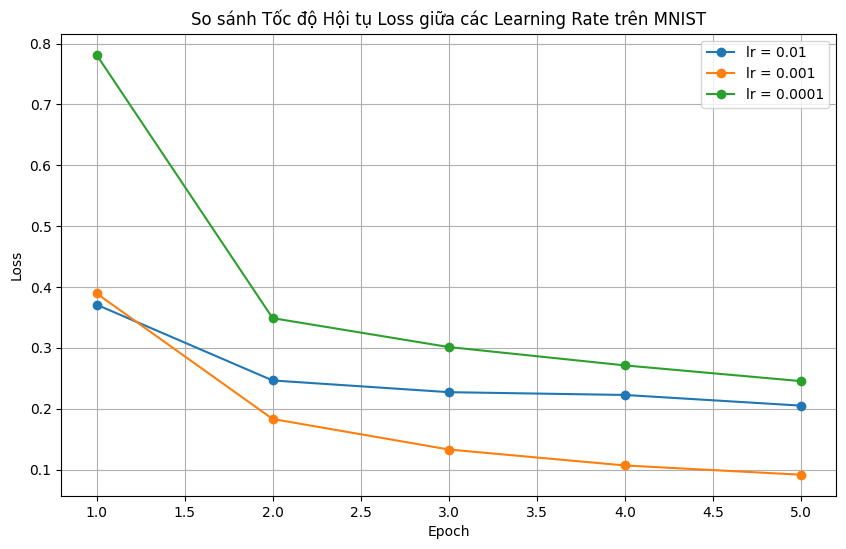

In [3]:
# BÀI 2: THỬ NGHIỆM VÀ VẼ ĐỒ THỊ SO SÁNH 3 LEARNING RATE
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Sử dụng lại lớp Model gốc (hoặc DeepANN phía trên tùy ý bạn chọn)
def train_with_lr(lr_value, train_loader, epochs=5):
    print(f"\n--- Đang huấn luyện với lr = {lr_value} ---")
    model = DeepANN() # Hoặc đổi thành tên class model gốc của bạn
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_value)

    loss_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        loss_history.append(epoch_loss)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

    return loss_history

# --- FIX START: Define train_loader ---
# Tải và chuẩn bị dữ liệu MNIST
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
# --- FIX END ---

# GIẢ ĐỊNH bạn đã có train_loader từ các cell chuẩn bị dữ liệu phía trên
# Chạy thử nghiệm thu thập lịch sử loss (ví dụ chạy 5 epoch để quan sát nhanh)
lrs = [1e-2, 1e-3, 1e-4]
histories = {}

for lr in lrs:
    # Bạn hãy chắc chắn rằng biến `train_loader` đã được chạy ở các ô dữ liệu phía trên nhé
    histories[lr] = train_with_lr(lr, train_loader, epochs=5)

# Vẽ đồ thị kết quả
plt.figure(figsize=(10, 6))
for lr, loss_vals in histories.items():
    plt.plot(range(1, len(loss_vals) + 1), loss_vals, marker='o', label=f"lr = {lr}")

plt.title("So sánh Tốc độ Hội tụ Loss giữa các Learning Rate trên MNIST")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# BÀI 3: THÊM DROPOUT ĐỂ KHỬ OVERFITTING

class ANNWithDropout(nn.Module):
    def __init__(self):
        super(ANNWithDropout, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu1 = nn.ReLU()

        # BÀI 3: Thêm lớp Dropout tỷ lệ 0.3
        self.dropout = nn.Dropout(p=0.3)

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.fc1(x)
        x = self.relu1(x)

        # Áp dụng dropout trong quá trình huấn luyện
        x = self.dropout(x)

        x = self.fc2(x)
        return x

print("Mô hình đã được tích hợp tầng Dropout:")
print(ANNWithDropout())

Mô hình đã được tích hợp tầng Dropout:
ANNWithDropout(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)



--- Đang huấn luyện mô hình cho Bài 4 ---
Epoch [1/3], Loss: 0.3921
Epoch [2/3], Loss: 0.1873
Epoch [3/3], Loss: 0.1387
--- Thống kê độ chính xác theo từng lớp (Per-class Accuracy) ---
Chữ số [0]: Độ chính xác = 98.47%
Chữ số [1]: Độ chính xác = 97.44%
Chữ số [2]: Độ chính xác = 95.35%
Chữ số [3]: Độ chính xác = 98.12%
Chữ số [4]: Độ chính xác = 92.06%
Chữ số [5]: Độ chính xác = 85.20%
Chữ số [6]: Độ chính xác = 94.78%
Chữ số [7]: Độ chính xác = 93.97%
Chữ số [8]: Độ chính xác = 96.61%
Chữ số [9]: Độ chính xác = 95.94%

--> Lớp mô hình nhận diện TỆ NHẤT là lớp: Chữ số 5 (85.20%


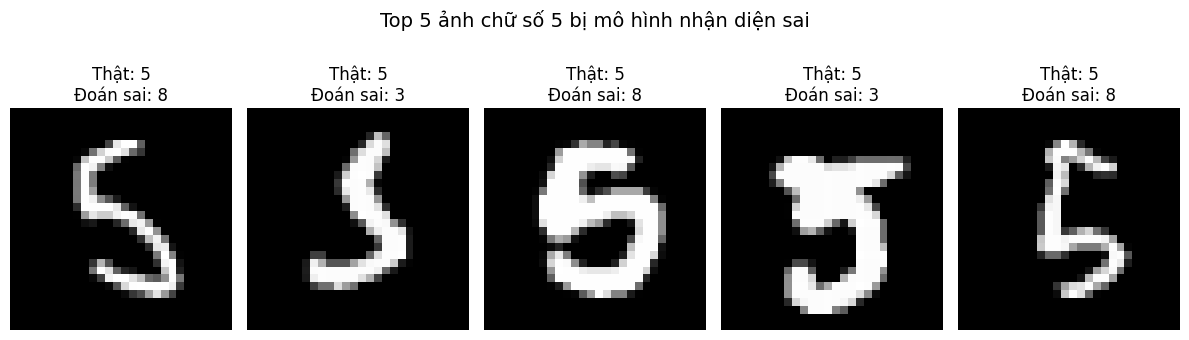

In [6]:
# BÀI 4: TÍNH ACCURACY THEO LỚP & IN 5 ẢNH ĐOÁN SAI TỆ NHẤT

import numpy as np
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt # Import matplotlib

# --- FIX START: Define dataset, train model, collect predictions ---
# Define transformations for the dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Load MNIST dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Create data loaders
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

# Instantiate the model (assuming DeepANN is defined in a previous cell)
model = DeepANN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3) # Use a reasonable learning rate

# Train the model for a few epochs to get a trained model for evaluation
print("\n--- Đang huấn luyện mô hình cho Bài 4 ---")
epochs = 3 # Train for a few epochs
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss / len(train_loader):.4f}")

# Evaluate the model and collect predictions
all_labels = []
all_preds = []
all_images = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_images.extend(images.cpu().numpy()) # Collect original images

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_images = np.array(all_images)

# Calculate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
# --- FIX END ---

print("--- Thống kê độ chính xác theo từng lớp (Per-class Accuracy) ---")
per_class_acc = []
for i in range(10):
    # Tránh chia cho 0 nếu lớp đó không có dữ liệu mẫu
    acc = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    per_class_acc.append(acc)
    print(f"Chữ số [{i}]: Độ chính xác = {acc * 100:.2f}%")

# Tìm lớp có độ chính xác thấp nhất
worst_class = np.argmin(per_class_acc)
print(f"\n--> Lớp mô hình nhận diện TỆ NHẤT là lớp: Chữ số {worst_class} ({per_class_acc[worst_class]*100:.2f}%")

# Trích xuất và hiển thị 5 ảnh của lớp tệ nhất bị dự đoán sai
incorrect_indices = np.where((all_labels == worst_class) & (all_preds != worst_class))[0]

fig, axes = plt.subplots(1, min(5, len(incorrect_indices)), figsize=(12, 4))
for idx, img_idx in enumerate(incorrect_indices[:5]):
    # Lấy ảnh gốc (Giả sử định dạng ảnh là 28x28)
    img = all_images[img_idx].reshape(28, 28)
    pred_label = all_preds[img_idx]

    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f"Thật: {worst_class}\nĐoán sai: {pred_label}")
    axes[idx].axis('off')

plt.suptitle(f"Top 5 ảnh chữ số {worst_class} bị mô hình nhận diện sai", fontsize=14)
plt.tight_layout()
plt.show()

Kích thước ma trận trọng số lớp fc1: (128, 784)


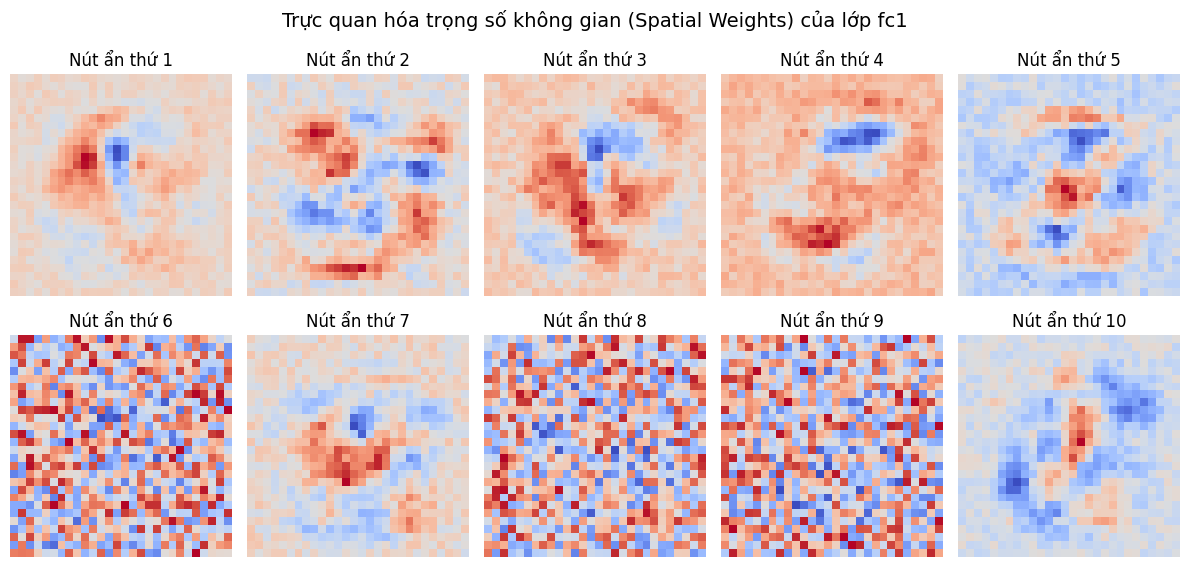

In [8]:
# BÀI 5: TRỰC QUAN HÓA TRỌNG SỐ LỚP TUYẾN TÍNH ĐẦU TIÊN (FC1)
import matplotlib.pyplot as plt

# Giả sử bạn lấy từ mô hình hiện tại đã train của mình: model_trained
weights = model.fc1.weight.detach().cpu().numpy() # Shape: [128, 784]

print(f"Kích thước ma trận trọng số lớp fc1: {weights.shape}")

# Tiến hành vẽ thử 10 nút nơ-ron đầu tiên của lớp ẩn fc1 dưới dạng ảnh 28x28
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    # Reshape trọng số nút thứ i từ 784 thành ảnh 28x28
    weight_img = weights[i].reshape(28, 28)

    # Dùng bản đồ màu 'viridis' hoặc 'coolwarm' để thấy rõ trọng số âm/dương
    im = ax.imshow(weight_img, cmap='coolwarm')
    ax.set_title(f"Nút ẩn thứ {i+1}")
    ax.axis('off')

plt.suptitle("Trực quan hóa trọng số không gian (Spatial Weights) của lớp fc1", fontsize=14)
plt.tight_layout()
plt.show()